# Download OW Faults from a specific fault set via DSIS

This notebook demonstrates how to query and explore fault data from DSIS using the `dsis-client` library.

Faults in OpenWorks are organized in a hierarchy:
- **FaultList** — a named collection of faults (e.g. "All faults for VOLVE_PUB")
- **FaultPlane** — a single interpreted fault surface (the level at which users select faults for transfer)
- **FaultSegment** — one polyline cross-section of a fault plane at a given horizon; multiple segments make up a full fault plane

The following steps are covered:

1. **Setup** — authenticate to DSIS using an `.env_dsis` file and connect the client.
2. **Query parameters** — configure the OW model, database, and project to query.
3. **Fetch all segments** — download all `FaultSegment` records for the project and visualize them as a 2-D map.
4. **Inspect z-domain** — print the Z unit and domain (TIME/DEPTH) per fault plane.
5. **Fetch segments for a single fault plane** — filter `FaultSegment` by `fault_plane_id`.
6. **Fetch fault metadata** — query `FaultPlane`, `FaultDisplay`, `FaultListMember`, `FaultTrimesh`, and `FaultCenterLine` for a given fault plane.

For more information about the required content of the `.env_dsis` file, please contact the SDD-SID team or the DSIS team in Equinor.


## 1. Setup

Import dependencies and authenticate to DSIS. Credentials and API keys are loaded from an `.env_dsis` file in the working directory. The file must contain the following keys: `tenant_id`, `client_id`, `client_secret`, `resource_id`, `dsis_function_key`, `dsis_password`, `subscription_key_dsauth`, `subscription_key_dsdata`, and optionally `dsis_site`.


In [153]:
%matplotlib inline
from dotenv import load_dotenv
import os
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import Iterable
import inspect
from dsis_client import DSISClient, DSISConfig, QueryBuilder, Environment

In [154]:
load_dotenv(".env_dsis")

True

In [155]:
config = DSISConfig(
    environment=Environment.PROD,
    tenant_id=os.getenv("tenant_id"),
    client_id=os.getenv("client_id"),
    client_secret=os.getenv("client_secret"),
    access_app_id=os.getenv("resource_id"),
    dsis_username=os.getenv("dsis_function_key"),
    dsis_password=os.getenv("dsis_password"),
    subscription_key_dsauth=os.getenv("subscription_key_dsauth"),
    subscription_key_dsdata=os.getenv("subscription_key_dsdata"),
    dsis_site=os.getenv("dsis_site"),
)

In [156]:
dsis_client = DSISClient(config)
if dsis_client.test_connection():
    print("✓ Connected to DSIS API")

✓ Connected to DSIS API


## 2. Query parameters

Set the OpenWorks model, model version, database (district), and project to query.

- `MODEL_NAME` — the OW model used to interpret the faults (e.g. `OW5000`). Controls the `district_id` format and which schemas are available.
- `MODEL_VERSION` — the schema version deployed in this DSIS instance.
- `DISTRICT` — the OpenWorks database name (used to build the `district_id`).
- `PROJECT` — the OpenWorks project containing the fault data.


In [157]:
MODEL_NAME = "OW5000"
MODEL_VERSION = "5000107"
DISTRICT = "BG4FROST"
PROJECT = "VOLVE_PUBLIC"

In [158]:
def build_district_id(database: str, *, model_name: str) -> str:
    """Build DSIS district_id from database name.

    DSIS uses different district-id conventions for different models.

    Examples:
    - OpenWorksCommonModel: OpenWorksCommonModel_OW_<DB>-OW_<DB>
    - OpenWorks native models (e.g., OW5000): OpenWorks_OW_<DB>_SingleSource-OW_<DB>
    """
    if model_name == "OpenWorksCommonModel":
        return f"OpenWorksCommonModel_OW_{database}-OW_{database}"
    return f"OpenWorks_OW_{database}_SingleSource-OW_{database}"


qkw: dict = {
    "district_id": build_district_id(DISTRICT, model_name=MODEL_NAME),
    "project": PROJECT,
}
if "model_name" in inspect.signature(QueryBuilder).parameters:
    qkw["model_name"] = MODEL_NAME

## 3. Fetch all fault segments

Fetch every `FaultSegment` record for the project. Each segment belongs to exactly one fault plane (`fault_plane_id`) and contains the projected X/Y/Z coordinates of one polyline cross-section. Multiple segments together define a complete fault surface.


In [159]:
def fetch_segments(client, qkw: dict) -> list[dict]:
    """Return all FaultSegment records that have values (x/y coordinates). FaultSegment is the DSIS schema which represents a single segment of a fault, with x/y coordinates stored in the "values" property.
    In some cases there may be FaultSegment records with no values (i.e., no coordinates) - these are filtered out. In other projects fault segments may be stored using a different schema, so this function
    may need to be modified accordingly."""
    return [
        seg
        for seg in client.execute_query(
            QueryBuilder(**qkw).schema("FaultSegment"), timeout=250
        )
        if seg.get("values")
    ]


def plot_fault_map(segments: Iterable[dict]) -> None:
    """Plot all faults as 2-D plan-view polylines, one colour per fault_plane_id.

    X = projected easting  (unit read from bounding_pt1_x_dsdsunit)
    Y = projected northing (unit read from bounding_pt1_y_dsdsunit)
    """
    by_plane: dict = defaultdict(list)
    x_unit = "None"
    y_unit = "None"
    for seg in segments:
        by_plane[seg["fault_plane_id"]].append(seg)
        x_unit = seg.get("bounding_pt1_x_dsdsunit")
        y_unit = seg.get("bounding_pt1_y_dsdsunit")

    if not by_plane:
        print("No segments to plot.")
        return

    plane_ids = list(by_plane.keys())
    cmap = plt.colormaps["tab20"]
    colours = [cmap(i % 20) for i in range(len(plane_ids))]

    fig, ax = plt.subplots(figsize=(10, 10))

    for colour, pid in zip(colours, plane_ids):
        for seg in by_plane[pid]:
            vals = seg["values"]
            x = [float(v) for v in vals["x"]]
            y = [float(v) for v in vals["y"]]
            ax.plot(x, y, color=colour, linewidth=1.0)

    n = len(plane_ids)
    ax.set_title(f"{PROJECT} — {n} fault{'s' if n != 1 else ''}")
    ax.set_aspect("equal")
    ax.grid(True, linewidth=0.4)
    ax.set_xlabel(f"Easting ({x_unit})")
    ax.set_ylabel(f"Northing ({y_unit})")
    plt.xticks(rotation=-70)
    plt.tight_layout()
    plt.show()

Fetch all `FaultSegment` records for the project and count how many unique fault planes are represented.


In [160]:
print("Fetching FaultSegments...")
segments = fetch_segments(dsis_client, qkw)
n_faults = len({s["fault_plane_id"] for s in segments})
print(f"  {len(segments)} segments across {n_faults} faults")

Fetching FaultSegments...
  1286 segments across 65 faults


Plot all fault segments as a 2-D plan view (easting/northing). Each fault plane is drawn in a distinct colour (cycling through 20 colours). Units are read from the segment metadata.


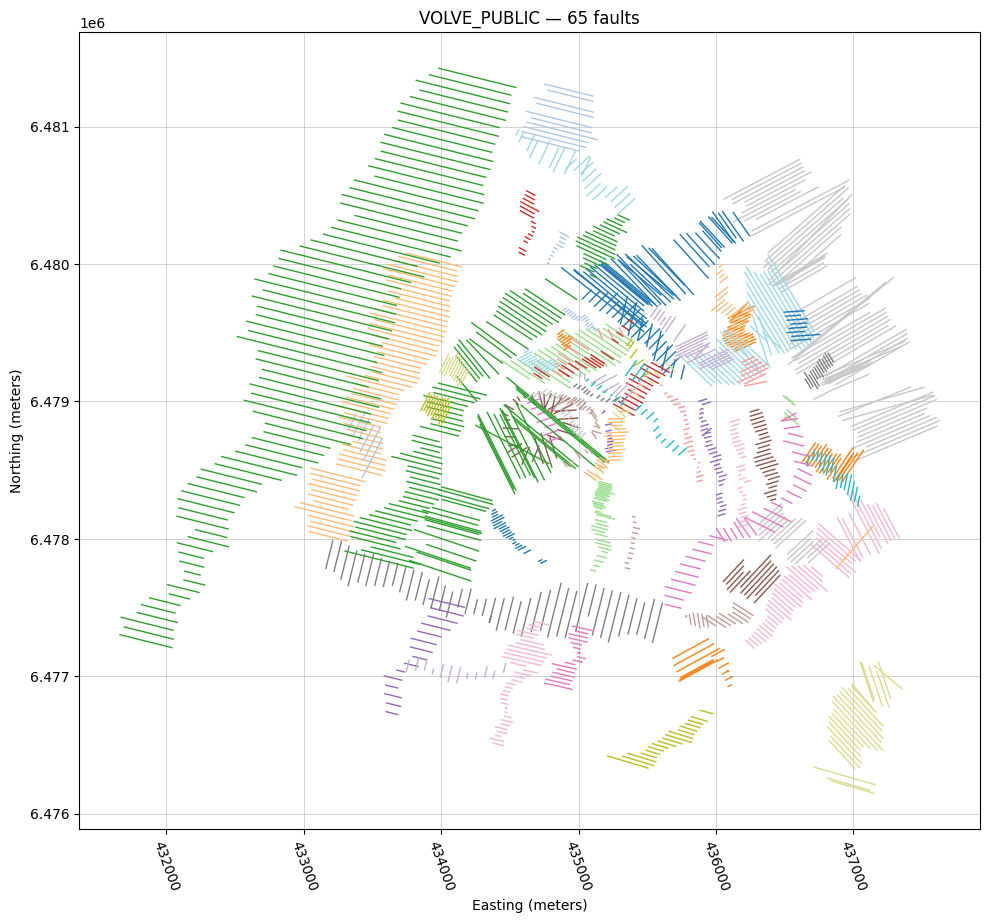

In [161]:
plot_fault_map(segments)

## 4. Inspect Z domain per fault plane

Print the Z unit (e.g. `ms`) and domain (`TIME` or `DEPTH`) for each fault plane. This is important to know before interpreting or converting depth values. In the Volve dataset all faults are in the TIME domain (two-way travel time in milliseconds).


In [162]:
by_plane: dict = defaultdict(list)
for seg in segments:
    by_plane[seg["fault_plane_id"]].append(seg)

print(f"\n{'fault_plane_id':<20} {'z_unit':<12} {'z_domain'}")
print("-" * 46)
for pid, segs in sorted(by_plane.items()):
    first = segs[0]
    z_unit = first.get("values_dsdsunit", "?")
    z_domain = (first.get("z_domain") or "UNKNOWN").upper()
    print(f"{pid:<20} {z_unit:<12} {z_domain}")


fault_plane_id       z_unit       z_domain
----------------------------------------------
4051                 ms           TIME
4053                 ms           TIME
4054                 ms           TIME
4055                 ms           TIME
4056                 ms           TIME
4057                 ms           TIME
4058                 ms           TIME
4059                 ms           TIME
4061                 ms           TIME
4062                 ms           TIME
4063                 ms           TIME
4064                 ms           TIME
4066                 ms           TIME
4072                 ms           TIME
4073                 ms           TIME
4074                 ms           TIME
4075                 ms           TIME
4076                 ms           TIME
4078                 ms           TIME
4079                 ms           TIME
4080                 ms           TIME
4081                 ms           TIME
4082                 ms           TIME
4083        

## 5. Fetch segments for a specific fault plane

To download only the segments belonging to one fault plane, filter `FaultSegment` by `fault_plane_id` — the same way `MappingPolygon` records are filtered by `mappingpolygonset_native_uid`.

Set `FAULT_PLANE_ID` to any ID from the table printed above.


In [163]:
# .expand() is called on the QueryBuilder (before execute_query), not on the result.
# It adds an OData $expand parameter to inline the related FaultSegment records directly
# inside each FaultPlane record, avoiding a second round-trip query.
import pprint

FAULT_PLANE_ID = 4321
expanded_results = list(
    dsis_client.execute_query(
        QueryBuilder(**qkw)
        .schema("FaultPlane")
        .filter(f"native_uid eq {FAULT_PLANE_ID}")
        .expand("FaultSegment"),
        timeout=60,
    )
)

plane = expanded_results[0] if expanded_results else {}
embedded_segments = plane.get("FaultSegment", [])
print(f"FaultPlane {FAULT_PLANE_ID}: {len(embedded_segments)} embedded FaultSegment(s)")
print(f"FaultPlane fault_name : {plane.get('fault_name')}")
print(f"FaultPlane z_domain   : {plane.get('z_domain')}")
print()
# Show the first embedded segment
if embedded_segments:
    print("First embedded FaultSegment:")
    pprint.pprint(embedded_segments[0])

FaultPlane 4321: 25 embedded FaultSegment(s)
FaultPlane fault_name : ST10010_2013b_171013_a_update
FaultPlane z_domain   : TIME

First embedded FaultSegment:
{'bounding_pt1_x': '435539.323168838',
 'bounding_pt1_x_dsdsunit': 'meters',
 'bounding_pt1_y': '6479337.38168744',
 'bounding_pt1_y_dsdsunit': 'meters',
 'bounding_pt2_x': '435539.323168838',
 'bounding_pt2_x_dsdsunit': 'meters',
 'bounding_pt2_y': '6479337.38168744',
 'bounding_pt2_y_dsdsunit': 'meters',
 'bounding_pt3_x': '435637.289045854',
 'bounding_pt3_x_dsdsunit': 'meters',
 'bounding_pt3_y': '6479434.62855032',
 'bounding_pt3_y_dsdsunit': 'meters',
 'bounding_pt4_x': '435637.289045854',
 'bounding_pt4_x_dsdsunit': 'meters',
 'bounding_pt4_y': '6479434.62855032',
 'bounding_pt4_y_dsdsunit': 'meters',
 'create_date': '2014-03-19T10:26:56.000',
 'create_user_id': 'SETER',
 'crs_id': 806,
 'data_source': 'STAT',
 'fault_plane_id': 4321,
 'fault_segment_id': '346993',
 'geom_set_type': '3D Survey',
 'horizon_attr_hdr_id': None

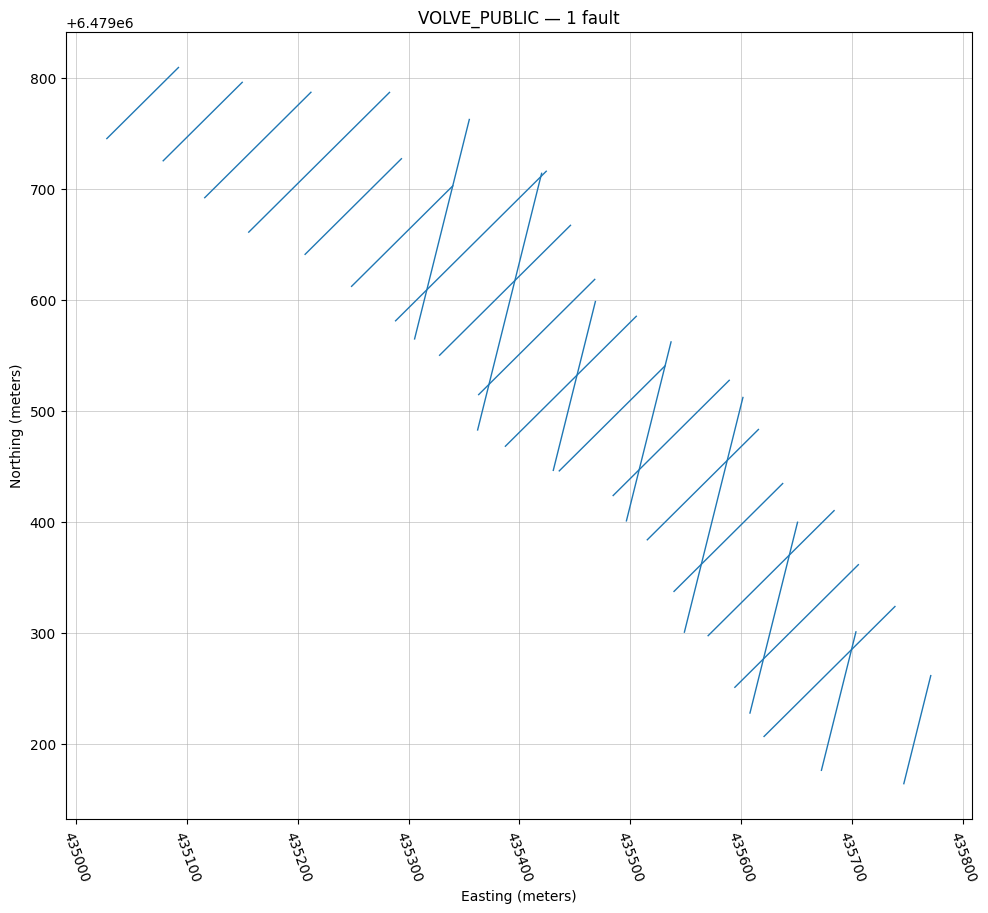

In [164]:
plot_fault_map(embedded_segments)

## 6. Fetch fault metadata for a specific fault plane

Three schemas carry metadata for a given fault plane, all joined via `fault_name`:

| Schema | Join key | What it contains |
|---|---|---|
| `FaultPlane` | `native_uid` = `fault_plane_id` | Interpretation metadata: name, z-domain, status, CRS |
| `Fault` | `fault_name` | Geological metadata: type (normal/reverse/…), heave, vertical separation |
| `FaultDisplay` | `fault_name` | Display colour (RGB), line style and weight |

> **Note:** `fault_name` is not an OData-filterable field on `Fault` or `FaultDisplay`. These schemas are fetched in full and matched in Python.


In [165]:
# 1. FaultPlane — interpretation metadata; native_uid is the fault_plane_id
fault_plane_results = list(
    dsis_client.execute_query(
        QueryBuilder(**qkw)
        .schema("FaultPlane")
        .filter(f"native_uid eq {FAULT_PLANE_ID}"),
        timeout=60,
    )
)
fault_plane = fault_plane_results[0] if fault_plane_results else {}
print(f"FaultPlane {FAULT_PLANE_ID}")
for key, value in fault_plane.items():
    print(f"{key:<25} : {value}")

FaultPlane 4321
interpretation_version_name : UNKNOWN
interpretation_status     : UNKNOWN
remark                    : None
fault_name                : ST10010_2013b_171013_a_update
update_user_id            : HEIGU
z_domain_qualifier        : None
z_domain                  : TIME
create_date               : 2014-03-19T10:18:09.000
fault_plane_id            : 4321
enable_triangulation      : Y
create_user_id            : SETER
native_uid                : 4321
data_source               : STAT
update_date               : 2014-10-16T13:36:40.000
segment_modification_date : 2014-10-16T13:36:40.000
original_data_source      : SETER


In [166]:
# FaultDisplay — display colour and line style, joined by fault_name
(display,) = [
    d
    for d in dsis_client.execute_query(
        QueryBuilder(**qkw).schema("FaultDisplay"), timeout=60
    )
    if d.get("name") == fault_plane["fault_name"]
    and d.get("data_source") == fault_plane["original_data_source"]
]
print("FaultDisplay")
for key, value in display.items():
    print(f"  {key:<30} : {value}")

FaultDisplay
  create_user_id                 : SETER
  native_uid                     : {"name":"ST10010_2013b_171013_a_update","data_source":"SETER"}
  color                          : 18
  line_style                     : 1
  data_source                    : SETER
  color_r                        : 0
  update_date                    : None
  display_ind                    : None
  original_data_source           : IHD
  color_g                        : 153
  update_user_id                 : None
  name                           : ST10010_2013b_171013_a_update
  line_weight                    : 1
  create_date                    : 2014-03-19T10:18:10.000
  color_b                        : 0


## Explore additional fault-related schemas

Beyond `FaultSegment` and `FaultPlane`, DSIS exposes several other schemas for a given fault plane. The cells below query each one and print the results.

| Schema | Filter key | What it contains |
|---|---|---|
| `FaultListMember` | `fault_plane_id` | Membership in named fault lists — the entry point for transfer selection |
| `FaultList` | `native_uid` (matched from `FaultListMember.list_id`) | Named fault collections with metadata |
| `FaultTrimesh` | `fault_plane_id` | 3-D triangulated mesh — an alternative to polyline segments |
| `FaultCenterLine` | `fault` field (= `fault_name`) | Pick-based centerline geometry with dip, heave, and vertical separation per point |
| `FaultCenterLineSet` | `fault_set_id` (from `FaultCenterLine`) | The interpretation set containing the centerlines |

In the Volve public dataset, only `FaultListMember` and `FaultList` return records for fault plane 4321. `FaultTrimesh` and `FaultCenterLine` are absent because this project stores only polyline segments.


In [167]:
print(
    "\nFaultTrimesh (if present) — 3D triangulated surface for fault plane; native_uid is the fault_plane_id"
)
print(
    list(
        dsis_client.execute_query(
            QueryBuilder(**qkw).schema("FaultTrimesh"), timeout=60
        )
    )
)
print(
    "\nFaultCenterLine — 3D line along centre of fault plane; native_uid is the fault_plane_id"
)
print(
    list(
        dsis_client.execute_query(
            QueryBuilder(**qkw).schema("FaultCenterLine"), timeout=60
        )
    )
)
print(
    "\nFaultCenterLineSet — set of 3D lines for all faults; native_uid is the fault_plane_id"
)
print(
    list(
        dsis_client.execute_query(
            QueryBuilder(**qkw).schema("FaultCenterLineSet"), timeout=60
        )
    )
)
print(
    "\nFaultListMember — list of all features belonging to a fault; filter by fault_plane_id"
)
print(
    list(
        dsis_client.execute_query(
            QueryBuilder(**qkw)
            .schema("FaultListMember")
            .filter(f"fault_plane_id eq {FAULT_PLANE_ID}"),
            timeout=60,
        )
    )
)
print("\nFaultList — list of all features belonging to project")
print(
    list(
        dsis_client.execute_query(
            QueryBuilder(**qkw).schema("FaultList"),
            timeout=60,
        )
    )
)


FaultTrimesh (if present) — 3D triangulated surface for fault plane; native_uid is the fault_plane_id
[]

FaultCenterLine — 3D line along centre of fault plane; native_uid is the fault_plane_id
[]

FaultCenterLineSet — set of 3D lines for all faults; native_uid is the fault_plane_id
[]

FaultListMember — list of all features belonging to a fault; filter by fault_plane_id
[{'create_user_id': 'VOLVE_PUB', 'native_uid': '{"list_id":140,"fault_plane_id":4321}', 'list_id': 140, 'update_user_id': None, 'create_date': '2018-05-15T08:35:23.000', 'update_date': None, 'fault_plane_id': 4321, 'order': None}]

FaultList — list of all features belonging to project
[{'create_user_id': 'VOLVE_PUB', 'original_data_source': None, 'native_uid': '140', 'list_id': '140', 'update_user_id': None, 'list_name': 'All faults for VOLVE_PUB', 'create_date': '2018-05-08T14:57:44.000', 'data_source': None, 'update_date': None}]


### Other fault-related schemas in DSIS

The following schemas from `dsis_model_sdk.models.common` are also relevant for faults:

| Schema | Key fields | Purpose |
|---|---|---|
| `Fault` | `fault_name`, `fault_type`, `heave_max` | High-level fault metadata — name, type (normal/reverse/…), displacement |
| `FaultList` | `list_name` | A named collection of faults (e.g. a fault set selected for transfer) |
| `FaultListMember` | `list_id`, `fault_plane_id` | Links a `FaultPlane` to a `FaultList`; the entry point when users select faults for transfer |
| `FaultTrimesh` | `fault_plane_id`, `min_z`, `max_z` | 3-D triangulated mesh per fault plane — alternative to polyline `FaultSegment`s |
| `FaultPlaneTrimesh` | `fault_name`, `domain` | Trimesh keyed by fault name and interpretation version |
| `FaultCenterLine` | `fault_set_id`, `data_domain` | Centerline geometry (pick-based representation) |
| `FaultCenterLineSet` | `fault_set_id`, `centerline_set_name` | Collection of centerlines |
| `FaultDisplay` | `fault_name`, `color_r/g/b` | Display colour per fault |

**Typical lookup pattern** — to go from a user's fault selection (a `FaultList`) down to geometry:

```
FaultList  →  FaultListMember.list_id  →  FaultListMember.fault_plane_id
           →  FaultPlane               →  FaultSegment  (polylines, this notebook)
                                       →  FaultTrimesh  (triangulated mesh)
```
